# **JobPredictor AI** - An AI powered job selection predictor

1. Import libraries

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

2. Loading the dataset

In [18]:
df = pd.read_csv("/content/AI_Resume_Screening.csv")
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


3. Data Cleaning

In [19]:
df.drop(
    [
        "Resume_ID",
        "Name"
    ],
    axis=1,
    inplace=True
)

In [20]:
df.isnull().sum()

,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0
AI Score (0-100),0


In [21]:
df.dropna(inplace=True)
print(df)

                                                Skills  Experience (Years)  \
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
5    Cybersecurity, Networking, Linux, Ethical Hacking                  10   
6           Networking, Cybersecurity, Ethical Hacking                   4   
..                                                 ...                 ...   
994                                        React, Java                   4   
996                    Deep Learning, Machine Learning                   0   
997                                    TensorFlow, NLP                   0   
998  Linux, Networking, Cybersecurity, Ethical Hacking                   8   
999       SQL, Machine Learning, Python, Deep Learning                   7   

    Education                Certifications               Job R

4. Target encoding

In [22]:
encoder = LabelEncoder()

df["Recruiter Decision"] = encoder.fit_transform(
    df["Recruiter Decision"]
)

5. Converting Categorical features

In [23]:
df.select_dtypes("object").columns

Index(['Skills', 'Education', 'Certifications', 'Job Role'], dtype='object')

In [24]:
df = pd.get_dummies(
    df,
    drop_first=True
)

6. Spliting the dataset

In [26]:
X = df.drop(
    [
        "Recruiter Decision",
        "AI Score (0-100)"
    ],
    axis=1
)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

7. Using Random Forest Model

In [28]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

8. Prediction

In [29]:
prediction = model.predict(
    X_test
)

9. Evaluation

In [30]:
accuracy_score(
    y_test,
    prediction
)
print(
classification_report(
    y_test,
    prediction
)
)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       129
           1       0.78      0.82      0.80        17

    accuracy                           0.95       146
   macro avg       0.88      0.90      0.89       146
weighted avg       0.95      0.95      0.95       146



10. Confusion matrix

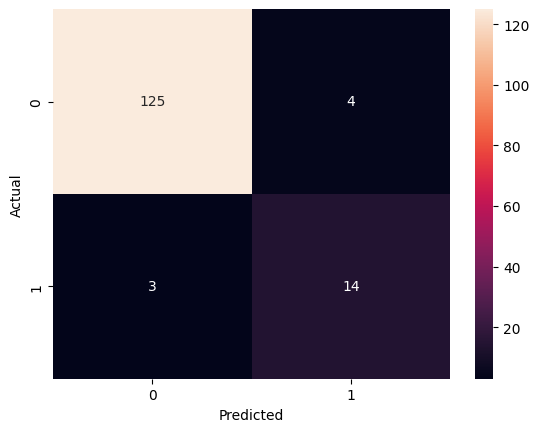

In [31]:
sns.heatmap(
    confusion_matrix(
        y_test,
        prediction
    ),
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

11. Feature Importance

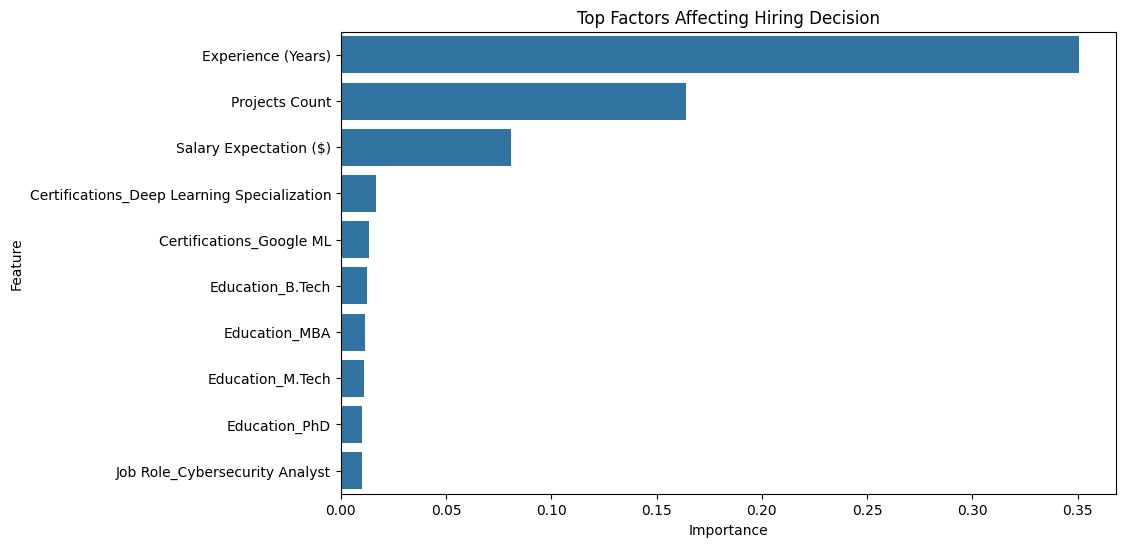

In [32]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    model.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))


sns.barplot(
    data=importance.sort_values(
        by="Importance",
        ascending=False
    ).head(10),

    x="Importance",

    y="Feature"
)


plt.title(
"Top Factors Affecting Hiring Decision"
)

plt.show()

12. Saving model and feature columns

In [33]:
pickle.dump(
    model,
    open(
        "resume_screening_model.pkl",
        "wb"
    )
)

pickle.dump(
    X.columns.tolist(),
    open(
        "columns.pkl",
        "wb"
    )
)

13. Conclusion : The accuracy of the model is ~ 95%